# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [40]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

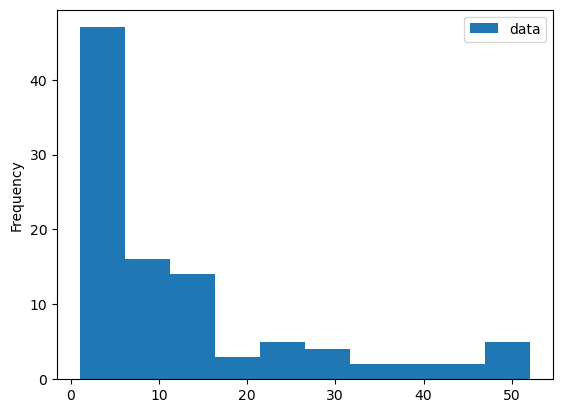

In [41]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

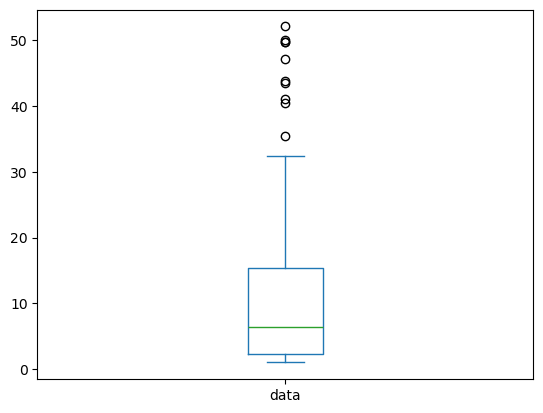

In [42]:
df.plot.box()

### Histogram Pros:

1. Shows overall distribution shapes - Quikly reveals if data is normal, skewed, bimodal or uniform
2. Easy to understand - Intuitive for most audiences; shows frequency/count directly
3. Reveals patterns - Can identify gaps, clusters, and concentration of values
4. Flexible binning - Adjusting bin width can reveal different patterns in the data

### Histogram Cons:

1. Hides individual data points - Cannot see actual values, only aggregated counts
2. Bin dependency - Different bin sizes can tell different stories; requires careful choice
3. Obscures outliers - Extreme values may be grouped or hidden at the edges
4. Poor for small datasets - Not effective when you have very few data points


### Boxplot Pros:

1. Summarizes key statistics - Shows median, quartiles, and range in one compact view
2. Highlights outliers - Clearly identifies data points that fall outside the expected range
3. Compact comparison - Excellent for comparing multiple groups side-by-side
4. Focuses on spread - Shows where middle 50% of data lies (IQR) at a glance


### Boxplot Cons:

1. Loses distribution detail - Cannot see if data is bimodal or has multiple peaks
2. Less intuitive - Requires explanation; many audiences don't understand quartiles
3. Hides sample size - Doesn't show how many data points are represented
4. Masks data quality issues - Missing values or data problems aren't visible

Given, I will choose boxplot because

1. It directly shows 75th percentile, which answers expensive drugs
2. It clearly seperates outliers(very expensive drugs) from typical prices

### To improve the visualization:
1. I will add axis labels with units ("Drug Price ($)")
2. Will add a title: "Distribution of Drug Prices"
3. Wil consider showing sample size (n=100)
4. If using histogram: will add a vertical line at 75th percentile with annotation

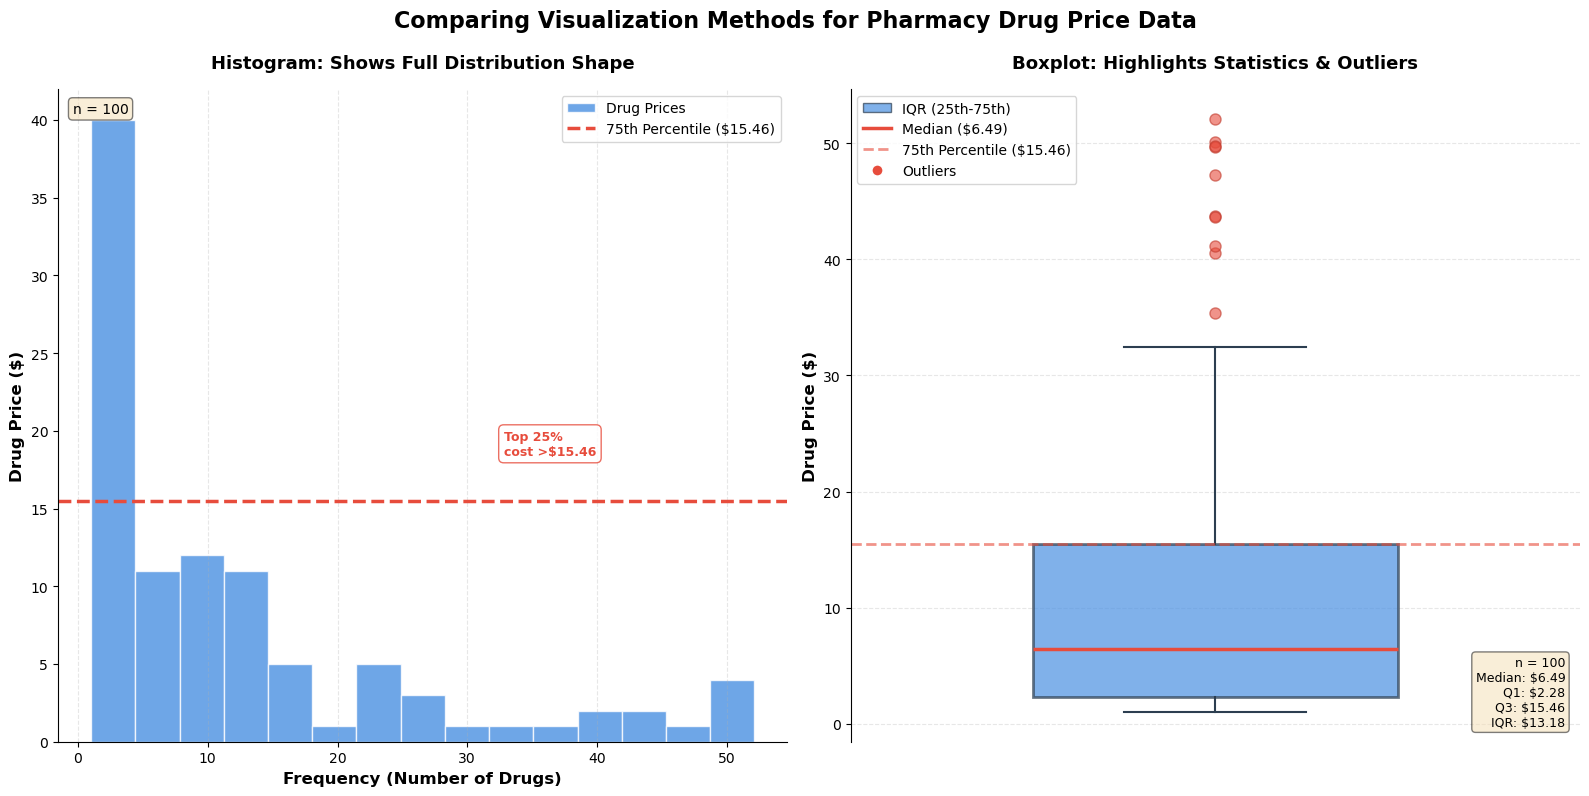


Visualization Comparison Summary:
Total drugs: 100
Median price: $6.49
75th percentile: $15.46
Top 25% of drugs cost: $15.46 or more


In [43]:
import matplotlib.pyplot as plt

# Create side-by-side comparison with complete labels and legends
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Calculate statistics
percentile_75 = df['data'].quantile(0.75)
q1 = df['data'].quantile(0.25)
median = df['data'].median()
q3 = df['data'].quantile(0.75)

# Left: Enhanced Histogram (VERTICAL orientation)
ax1.hist(df['data'], bins=15, color='#4A90E2', edgecolor='white', alpha=0.8, 
         orientation='vertical', label='Drug Prices')
ax1.axhline(percentile_75, color='#E74C3C', linestyle='--', linewidth=2.5,
           label=f'75th Percentile (${percentile_75:.2f})')
ax1.set_ylabel('Drug Price ($)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Frequency (Number of Drugs)', fontsize=12, fontweight='bold')
ax1.set_title('Histogram: Shows Full Distribution Shape', fontsize=13, fontweight='bold', pad=15)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(loc='upper right', fontsize=10)

# Add sample size annotation
ax1.text(0.02, 0.98, f'n = {len(df)}', transform=ax1.transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add text annotation for 75th percentile
ax1.text(ax1.get_xlim()[1] * 0.6, percentile_75 + 3, 
         f'Top 25%\ncost >${percentile_75:.2f}', 
         color='#E74C3C', fontsize=9, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#E74C3C', alpha=0.8))

# Right: Enhanced Boxplot (VERTICAL)
bp = ax2.boxplot(df['data'], patch_artist=True, widths=0.5,
                 boxprops=dict(facecolor='#4A90E2', alpha=0.7, edgecolor='#2C3E50', linewidth=2),
                 medianprops=dict(color='#E74C3C', linewidth=2.5),
                 whiskerprops=dict(color='#2C3E50', linewidth=1.5),
                 capprops=dict(color='#2C3E50', linewidth=1.5),
                 flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=8, 
                                markeredgecolor='#C0392B', alpha=0.6))

ax2.set_ylabel('Drug Price ($)', fontsize=12, fontweight='bold')
ax2.set_xlabel('', fontsize=12)
ax2.set_title('Boxplot: Highlights Statistics & Outliers', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks([])
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)

# Add horizontal line at 75th percentile for comparison
ax2.axhline(percentile_75, color='#E74C3C', linestyle='--', linewidth=2, alpha=0.6,
           label=f'75th Percentile (${percentile_75:.2f})')

# Create custom legend entries for boxplot components
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#4A90E2', alpha=0.7, edgecolor='#2C3E50', label='IQR (25th-75th)'),
    Line2D([0], [0], color='#E74C3C', linewidth=2.5, label=f'Median (${median:.2f})'),
    Line2D([0], [0], color='#E74C3C', linewidth=2, linestyle='--', alpha=0.6, 
           label=f'75th Percentile (${percentile_75:.2f})'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E74C3C', 
           markersize=8, label='Outliers')
]
ax2.legend(handles=legend_elements, loc='upper left', fontsize=10)

# Add statistics text box
iqr = q3 - q1
stats_text = f'n = {len(df)}\nMedian: ${median:.2f}\nQ1: ${q1:.2f}\nQ3: ${q3:.2f}\nIQR: ${iqr:.2f}'
ax2.text(0.98, 0.02, stats_text, transform=ax2.transAxes,
        fontsize=9, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Add main title
fig.suptitle('Comparing Visualization Methods for Pharmacy Drug Price Data', 
             fontsize=16, fontweight='bold', y=0.99)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nVisualization Comparison Summary:")
print(f"{'='*50}")
print(f"Total drugs: {len(df)}")
print(f"Median price: ${median:.2f}")
print(f"75th percentile: ${percentile_75:.2f}")
print(f"Top 25% of drugs cost: ${q3:.2f} or more")

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [44]:
# IBM Anti Money Laundering Data
df_original = pd.read_csv('../../data/default_of_credit_card_clients.csv')
df = df_original.drop(columns=['ID', 'DEFAULT_PAYMENT_NEXT_MONTH']).copy()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

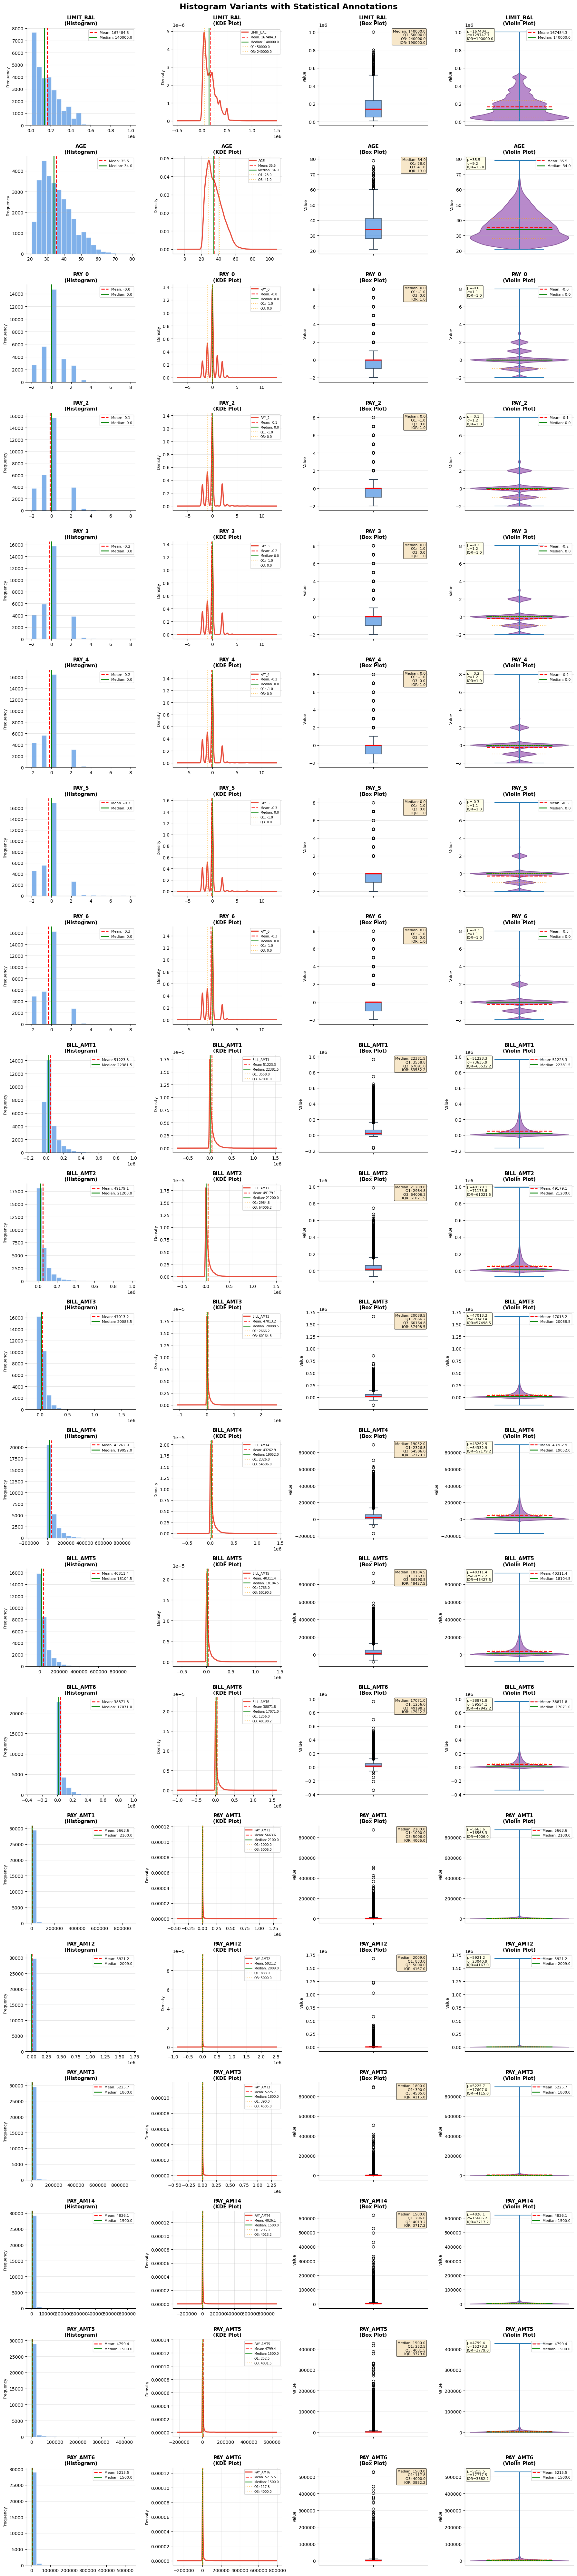

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create histograms
# axes = df.hist(bins=20, figsize=(18, 14), edgecolor='white', alpha=0.7)

# Get numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_encoded = ['SEX', 'EDUCATION', 'MARRIAGE']
numeric_cols = [col for col in numeric_cols if col not in categorical_encoded]

fig, axes = plt.subplots(len(numeric_cols), 4, figsize=(18, len(numeric_cols) * 4))

for i, col in enumerate(numeric_cols):
    # Calculate statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    std_val = df[col].std()
    
    # 1. HISTOGRAM with Mean and Median
    axes[i, 0].hist(df[col], bins=20, edgecolor='white', alpha=0.7, color='#4A90E2')
    axes[i, 0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    axes[i, 0].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}')
    axes[i, 0].set_title(f'{col}\n(Histogram)', fontweight='bold', fontsize=11)
    axes[i, 0].set_ylabel('Frequency', fontsize=9)
    axes[i, 0].grid(axis='y', alpha=0.3)
    axes[i, 0].legend(loc='upper right', fontsize=8)
    axes[i, 0].spines['top'].set_visible(False)
    axes[i, 0].spines['right'].set_visible(False)
    
    # 2. KDE PLOT with Mean, Median, and Quartiles
    df[col].plot.kde(ax=axes[i, 1], color='#E74C3C', linewidth=2.5)
    axes[i, 1].axvline(mean_val, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Mean: {mean_val:.1f}')
    axes[i, 1].axvline(median_val, color='green', linestyle='-', linewidth=2, alpha=0.7, label=f'Median: {median_val:.1f}')
    axes[i, 1].axvline(q1, color='orange', linestyle=':', linewidth=1.5, alpha=0.6, label=f'Q1: {q1:.1f}')
    axes[i, 1].axvline(q3, color='orange', linestyle=':', linewidth=1.5, alpha=0.6, label=f'Q3: {q3:.1f}')
    axes[i, 1].set_title(f'{col}\n(KDE Plot)', fontweight='bold', fontsize=11)
    axes[i, 1].set_ylabel('Density', fontsize=9)
    axes[i, 1].grid(alpha=0.3)
    axes[i, 1].legend(loc='upper right', fontsize=7)
    axes[i, 1].spines['top'].set_visible(False)
    axes[i, 1].spines['right'].set_visible(False)
    
    # 3. BOX PLOT with Labeled Statistics
    bp = axes[i, 2].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                            boxprops=dict(facecolor='#4A90E2', alpha=0.7, edgecolor='#2C3E50', linewidth=1.5),
                            whiskerprops=dict(color='#2C3E50', linewidth=1.5),
                            capprops=dict(color='#2C3E50', linewidth=1.5),
                            medianprops=dict(color='red', linewidth=2.5))
    axes[i, 2].set_title(f'{col}\n(Box Plot)', fontweight='bold', fontsize=11)
    axes[i, 2].set_ylabel('Value', fontsize=9)
    axes[i, 2].grid(axis='y', alpha=0.3)
    axes[i, 2].set_xticklabels([''])
    axes[i, 2].spines['top'].set_visible(False)
    axes[i, 2].spines['right'].set_visible(False)
    
    # Add text annotations for box plot statistics
    stats_text = f'Median: {median_val:.1f}\nQ1: {q1:.1f}\nQ3: {q3:.1f}\nIQR: {iqr:.1f}'
    axes[i, 2].text(0.98, 0.98, stats_text, transform=axes[i, 2].transAxes,
                   fontsize=8, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    # 4. VIOLIN PLOT with Mean and Median lines
    parts = axes[i, 3].violinplot([df[col].dropna()], positions=[0], 
                                  showmeans=False, showmedians=False)
    for pc in parts['bodies']:
        pc.set_facecolor('#9B59B6')
        pc.set_alpha(0.7)
        pc.set_edgecolor('#6C3483')
        pc.set_linewidth(1.5)
    
    # Add horizontal lines for mean and median
    axes[i, 3].axhline(mean_val, color='red', linestyle='--', linewidth=2, 
                      xmin=0.2, xmax=0.8, label=f'Mean: {mean_val:.1f}')
    axes[i, 3].axhline(median_val, color='green', linestyle='-', linewidth=2, 
                      xmin=0.2, xmax=0.8, label=f'Median: {median_val:.1f}')
    axes[i, 3].axhline(q1, color='orange', linestyle=':', linewidth=1.5, 
                      xmin=0.25, xmax=0.75, alpha=0.6)
    axes[i, 3].axhline(q3, color='orange', linestyle=':', linewidth=1.5, 
                      xmin=0.25, xmax=0.75, alpha=0.6)
    
    axes[i, 3].set_title(f'{col}\n(Violin Plot)', fontweight='bold', fontsize=11)
    axes[i, 3].set_ylabel('Value', fontsize=9)
    axes[i, 3].grid(axis='y', alpha=0.3)
    axes[i, 3].set_xticks([])
    axes[i, 3].legend(loc='upper right', fontsize=8)
    axes[i, 3].spines['top'].set_visible(False)
    axes[i, 3].spines['right'].set_visible(False)
    
    # Add statistics summary text
    summary_text = f'μ={mean_val:.1f}\nσ={std_val:.1f}\nIQR={iqr:.1f}'
    axes[i, 3].text(0.02, 0.98, summary_text, transform=axes[i, 3].transAxes,
                   fontsize=8, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.suptitle('Histogram Variants with Statistical Annotations', 
             fontsize=18, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

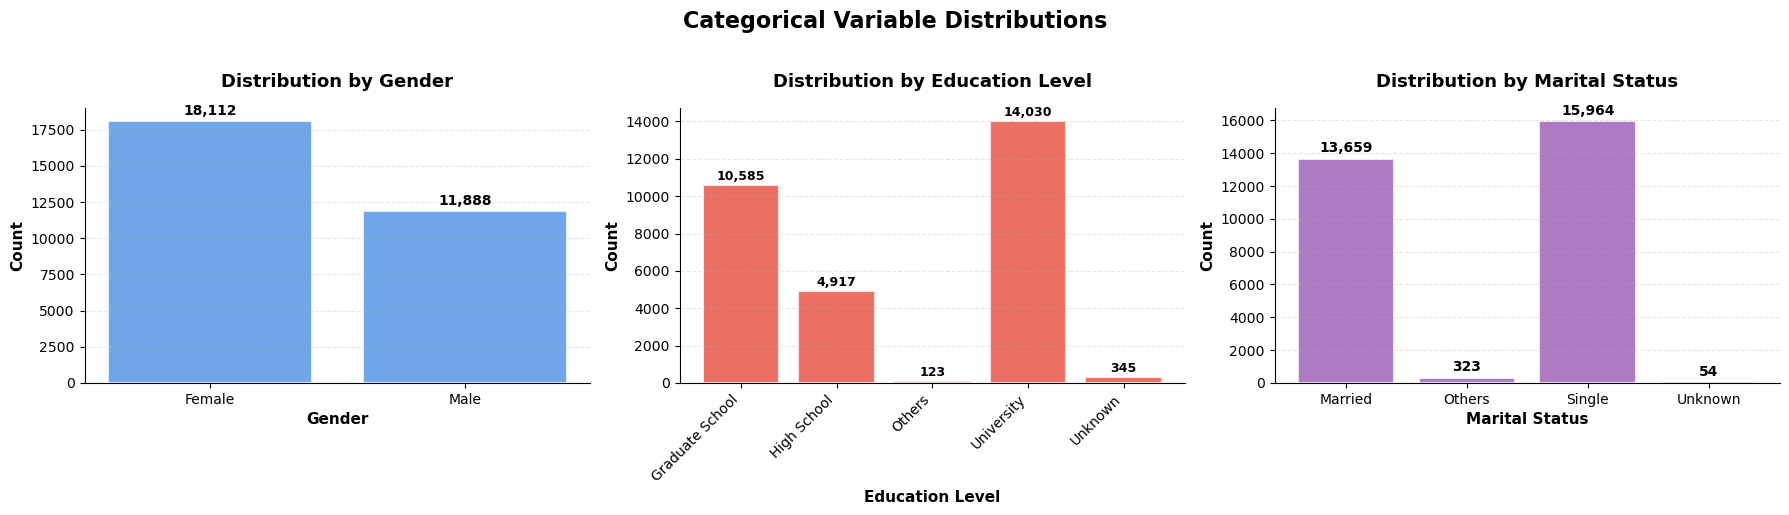

Categorical Variable Summary:

Gender Distribution:
SEX
Female    18112
Male      11888
Name: count, dtype: int64

Education Distribution:
EDUCATION
Graduate School    10585
High School         4917
Others               123
University         14030
Unknown              345
Name: count, dtype: int64

Marital Status Distribution:
MARRIAGE
Married    13659
Others       323
Single     15964
Unknown       54
Name: count, dtype: int64


In [46]:

# Create a copy of the dataframe for visualization
df_display = df.copy()

# Map numeric values to categorical labels
# Based on UCI Credit Card Default dataset documentation

# SEX: 1 = Male, 2 = Female
df_display['SEX'] = df['SEX'].map({
    1: 'Male',
    2: 'Female'
})

# EDUCATION: 1 = Graduate school, 2 = University, 3 = High school, 4 = Others
df_display['EDUCATION'] = df['EDUCATION'].map({
    1: 'Graduate School',
    2: 'University',
    3: 'High School',
    4: 'Others',
    5: 'Unknown',  # Sometimes there are values 5, 6, 0
    6: 'Unknown',
    0: 'Unknown'
})

# MARRIAGE: 1 = Married, 2 = Single, 3 = Others
df_display['MARRIAGE'] = df['MARRIAGE'].map({
    1: 'Married',
    2: 'Single',
    3: 'Others',
    0: 'Unknown'  # Sometimes there's 0
})

# Create bar plots for categorical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SEX
sex_counts = df_display['SEX'].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values, color='#4A90E2', alpha=0.8, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution by Gender', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Gender', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0, labelsize=10)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
# Add value labels on bars
for i, (idx, val) in enumerate(zip(sex_counts.index, sex_counts.values)):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# EDUCATION
edu_counts = df_display['EDUCATION'].value_counts().sort_index()
axes[1].bar(range(len(edu_counts)), edu_counts.values, color='#E74C3C', alpha=0.8, edgecolor='white', linewidth=1.5)
axes[1].set_xticks(range(len(edu_counts)))
axes[1].set_xticklabels(edu_counts.index, rotation=45, ha='right')
axes[1].set_title('Distribution by Education Level', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Education Level', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1].tick_params(labelsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
# Add value labels on bars
for i, val in enumerate(edu_counts.values):
    axes[1].text(i, val + 100, f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# MARRIAGE
marriage_counts = df_display['MARRIAGE'].value_counts().sort_index()
axes[2].bar(range(len(marriage_counts)), marriage_counts.values, color='#9B59B6', alpha=0.8, edgecolor='white', linewidth=1.5)
axes[2].set_xticks(range(len(marriage_counts)))
axes[2].set_xticklabels(marriage_counts.index, rotation=0)
axes[2].set_title('Distribution by Marital Status', fontsize=13, fontweight='bold', pad=15)
axes[2].set_xlabel('Marital Status', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[2].tick_params(labelsize=10)
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
# Add value labels on bars
for i, val in enumerate(marriage_counts.values):
    axes[2].text(i, val + 200, f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Categorical Variable Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary
print("Categorical Variable Summary:")
print("="*60)
print(f"\nGender Distribution:")
print(sex_counts)
print(f"\nEducation Distribution:")
print(edu_counts)
print(f"\nMarital Status Distribution:")
print(marriage_counts)

In [47]:
# calculate the mean and median for all numeric columns, then identifty the mode for all columns.
means = df.mean(numeric_only=True)
medians = df.median(numeric_only=True)
mins = df.min(numeric_only=True)
maxs = df.max(numeric_only=True)
modes = df.mode().iloc[0] 

summary_df = pd.DataFrame([means, medians, modes, mins, maxs], index=['mean', 'median', 'mode', 'min', 'max'])
summary_df

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
mean,167484.322667,1.603733,1.853133,1.551867,35.4855,-0.0167,-0.133767,-0.1662,-0.220667,-0.2662,...,4.701315e+04,43262.948967,40311.400967,38871.7604,5663.5805,5.921163e+03,5225.6815,4826.076867,4799.387633,5215.502567
median,140000.000000,2.000000,2.000000,2.000000,34.0000,0.0000,0.000000,0.0000,0.000000,0.0000,...,2.008850e+04,19052.000000,18104.500000,17071.0000,2100.0000,2.009000e+03,1800.0000,1500.000000,1500.000000,1500.000000
mode,50000.000000,2.000000,2.000000,2.000000,29.0000,0.0000,0.000000,0.0000,0.000000,0.0000,...,0.000000e+00,0.000000,0.000000,0.0000,0.0000,0.000000e+00,0.0000,0.000000,0.000000,0.000000
min,10000.000000,1.000000,0.000000,0.000000,21.0000,-2.0000,-2.000000,-2.0000,-2.000000,-2.0000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.0000,0.0000,0.000000e+00,0.0000,0.000000,0.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.0000,8.0000,8.000000,8.0000,8.000000,8.0000,...,1.664089e+06,891586.000000,927171.000000,961664.0000,873552.0000,1.684259e+06,896040.0000,621000.000000,426529.000000,528666.000000


### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

    1. The LIMIT_BAl (credit limit) shows a right skewed distribution, which is expected in financial data where most customers have moderate credit limits, while a few have very high limits.
    2. AGE distribution appears relatively normal with a concentration between 25-45 years, which aligns with the typical credit card user demographic.
    3. Yes, the dataset appears clean with no missing values (Have not done preprocessing).


- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

    1. LIMIT_BAL, BILL_AMT columns show right skewness (mean > median)
    2. Mean: $167484.322667, Median: $140000.000000, suggesting the presence of high-value outliers
    3. SEX, EDUCATION, MARRIAGE show discrete categories
    4. AGE appears approximately normal with mean ≈ median
    5. Payment Variables (PAY_0 through PAY_6) 


- Are there any outliers present?  (Data points that are far from the others.)

    Based on boxplot visualizations and IQR calculations:
    1. BILL_AMT - Significant outliers detected above Q3 + 1.5*IQR, These represent customers with unusually high bill amounts.
    2. PAY_AMT - Outliers present in payment amounts, Could represent large one-time payments or payment plan settlements
    3. LIMIT_BAL - Some extreme values at the upper end, These represent customers with premium credit limits



- If there are multiple related histograms, how does the distribution change across different groups?

    When comparing distributions between defaulters and non-defaulters (from grouped histograms):
    1. LIMIT_BAL : Non-defaulters tend to have higher credit limits on average, suggesting creditworthiness correlation
    2. AGE: Both groups show similar age distributions, indicating age alone may not be a strong predictor
    3. BILL_AMT: Defaulters show slightly higher bill amounts relative to their credit limits
    4. PAY_STATUS: Defaulters have noticeably more delayed payment history (higher PAY values)


- What are the minimum and maximum values represented in each histogram?

    1. BILL_AMT : -1.572640e+05, 1.664089e+06
    2. AGE : 21.0000, 79.0000
    3. LIMIT_BAL : 10000.000000 , 1000000.000000



- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

    1. Fewer Bins (10-15) - Provides smoother, more general view of distribution, Better for identifying overall shape (skew, modality)
    2. Moderate Bins (20-30) - Balanced view showing both overall shape and detail, Optimal for most features in this dataset, Clearly shows concentration points without excessive noise
    3. Many Bins (40+) - Reveals fine-grained patterns, Can become noisy and harder to interpret, Useful for identifying multiple modes or gaps in data


- Does the distribution appear normal, or does it have a different distribution?
    1. LIMIT_BAL :  Right-skewed (Log-normal) | Long right tail, median < mean |
    2. AGE : Approximately Normal | Symmetric, mean ≈ median |
    3. BILL_AMT1-6 : Right-skewed | Most customers have moderate bills |
    4. PAY_AMT1-6 : Right-skewed | Concentration at lower payment amounts |
    5. SEX, EDUCATION, MARRIAGE : Categorical/Discrete | Not applicable for normality |
    6. PAY_0 through PAY_6: Discrete distribution | Concentration around 0 (on-time payment), with some negative values (advance payment) and positive values (delayed payment)

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_12645/2659897211.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_age = df_original.groupby(pd.cut(df['AGE'], bins=[20, 30, 40, 50, 60, 80]))['DEFAULT_PAYMENT_NEXT_MONTH'].mean() * 100


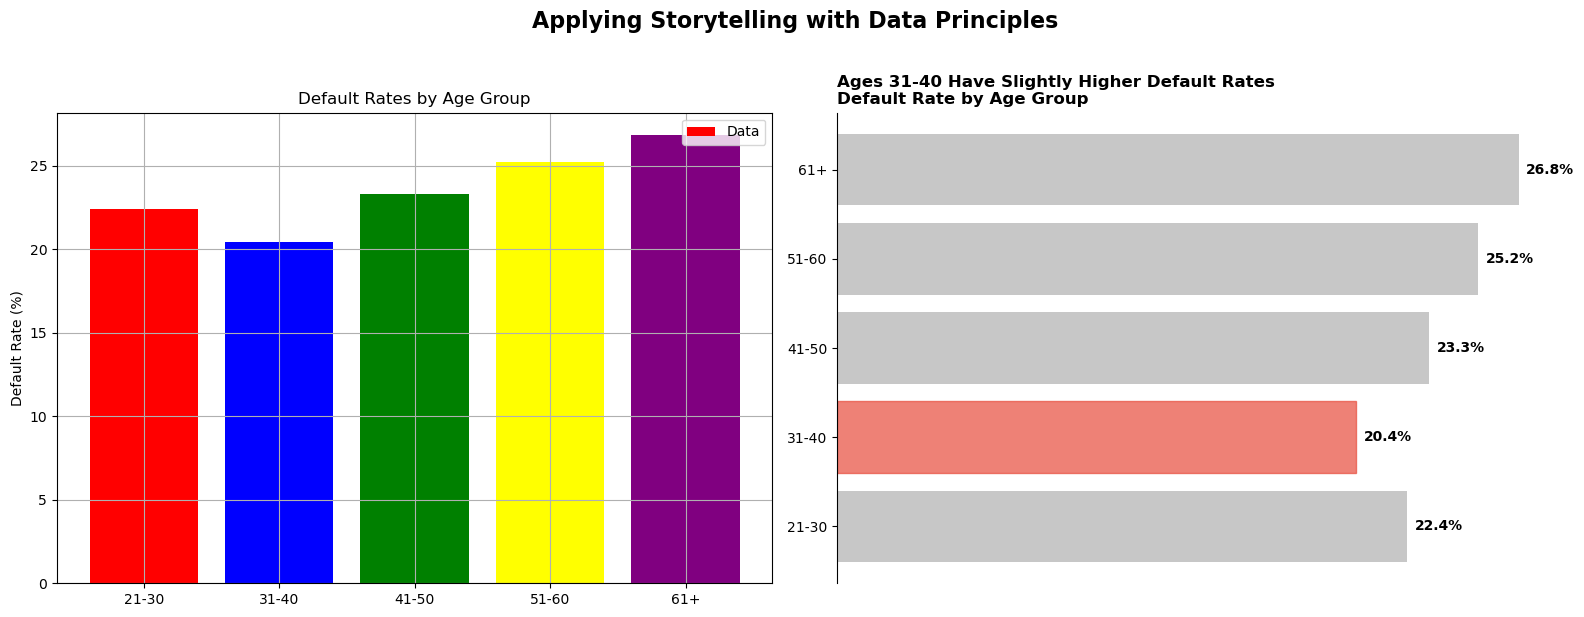

In [48]:
# Show how to improve a cluttered chart into a clean SWD-style chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: "Before" - Cluttered chart
default_by_age = df_original.groupby(pd.cut(df['AGE'], bins=[20, 30, 40, 50, 60, 80]))['DEFAULT_PAYMENT_NEXT_MONTH'].mean() * 100
age_groups = ['21-30', '31-40', '41-50', '51-60', '61+']

ax1.bar(age_groups, default_by_age, color=['red', 'blue', 'green', 'yellow', 'purple'])
ax1.set_title('Default Rates by Age Group')
ax1.set_ylabel('Default Rate (%)')
ax1.grid(True)
ax1.legend(['Data'], loc='upper right')

# RIGHT: "After" - Clean SWD style
bars = ax2.barh(age_groups, default_by_age, color='#B0B0B0', alpha=0.7)
bars[1].set_color('#E74C3C')  # Highlight key insight

# Direct labels
for i, rate in enumerate(default_by_age):
    ax2.text(rate + 0.3, i, f'{rate:.1f}%', va='center', fontsize=10, fontweight='bold')

# Clean styling
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.set_xticks([])
ax2.set_title('Ages 31-40 Have Slightly Higher Default Rates\nDefault Rate by Age Group', 
             fontsize=12, fontweight='bold', loc='left')

fig.suptitle('Applying Storytelling with Data Principles', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()